In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import gamma
from scipy.stats import weibull_min
from scipy.stats import nbinom

# 1. Exploratory Data Analysis - Train dataset

Download original train dataset

In [ ]:
# df_original=pd.read_csv("data/train.csv")
# df_original.head()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,7,7,0,1500-1559,3,3,26,160,American Airlines Inc.,19534,...,Chicago O'Hare International,0.00,0.0,0.0,95.0,4.25,0.237709,0.273236,0.222538,0.255479
1,4,1,0,1300-1359,4,4,63,50,SkyWest Airlines Inc.,18788,...,El Paso International,0.00,0.0,0.0,71.0,11.41,0.154651,0.121849,0.237972,0.197503
2,11,4,0,0001-0559,2,1,3,76,American Eagle Airlines Inc.,1148,...,NONE,0.00,0.0,0.0,54.0,0.45,0.117559,0.187867,0.139886,0.060327
3,3,2,0,1500-1559,7,5,14,143,Southwest Airlines Co.,7612,...,San Jose International,0.00,0.0,0.0,64.0,8.05,0.204389,0.141446,0.132868,0.202037
4,7,3,0,0800-0859,1,2,85,50,American Eagle Airlines Inc.,29376,...,Cincinnati/Northern Kentucky International,0.01,0.0,0.0,94.0,10.51,0.203263,0.193761,0.203027,0.113050


Select relevant variables and save the new dataset

In [ ]:
# df_train = df_original[["MONTH", "DAY_OF_WEEK", "DEP_DEL15", "CONCURRENT_FLIGHTS", "CARRIER_NAME", "PRCP", "AWND", "DEPARTING_AIRPORT", "LATITUDE", "LONGITUDE"]]
# df_train = df_train.rename(columns={"DEP_DEL15": "DELAY", "AWND":"WIND"})
# df_train.to_csv("data/train_filter.csv", index=False)
# print(f"Number of observations: {len(df_train)}")
# df_train.head()

Number of observations: 4542343


,MONTH,DAY_OF_WEEK,DELAY,CONCURRENT_FLIGHTS,CARRIER_NAME,PRCP,WIND,DEPARTING_AIRPORT,LATITUDE,LONGITUDE
0,7,7,0,26,American Airlines Inc.,0.00,4.25,Douglas Municipal,35.219,-80.936
1,4,1,0,63,SkyWest Airlines Inc.,0.00,11.41,Stapleton International,39.774,-104.880
2,11,4,0,3,American Eagle Airlines Inc.,0.00,0.45,Adams Field,34.729,-92.234
3,3,2,0,14,Southwest Airlines Co.,0.00,8.05,San Diego International Lindbergh Fl,32.733,-117.187
4,7,3,0,85,American Eagle Airlines Inc.,0.01,10.51,Chicago O'Hare International,41.978,-87.906


Download new dataset and check for missing values

In [134]:
df_train=pd.read_csv("data/train_filter.csv")
print(df_train.isna().sum())

MONTH                 0
DAY_OF_WEEK           0
DELAY                 0
CONCURRENT_FLIGHTS    0
CARRIER_NAME          0
PRCP                  0
WIND                  0
DEPARTING_AIRPORT     0
LATITUDE              0
LONGITUDE             0
dtype: int64


## 1.2. Categorical Variables

### Month

In [135]:
df_train["MONTH"].value_counts().sort_index()

MONTH
1     351390
2     315785
3     387505
4     373800
5     390479
6     389812
7     404984
8     406093
9     370721
10    393106
11    372259
12    386409
Name: count, dtype: int64

### Day of Week

In [136]:
df_train["DAY_OF_WEEK"].value_counts().sort_index()

DAY_OF_WEEK
1    676815
2    662339
3    656193
4    669146
5    678895
6    552926
7    646029
Name: count, dtype: int64

### Delay (Class)

Classes are not balanced

In [137]:
df_train["DELAY"].value_counts().sort_index()

DELAY
0    3683185
1     859158
Name: count, dtype: int64

### Carrier

In [141]:
print(f"Number of airlines: {len(df_train["CARRIER_NAME"].unique())}")
df_train["CARRIER_NAME"].value_counts()

Number of airlines: 17


CARRIER_NAME
Southwest Airlines Co.          907076
Delta Air Lines Inc.            657062
American Airlines Inc.          632771
United Air Lines Inc.           420624
SkyWest Airlines Inc.           409126
Midwest Airline, Inc.           210298
JetBlue Airways                 188402
Alaska Airlines Inc.            167595
American Eagle Airlines Inc.    160390
Comair Inc.                     153365
Endeavor Air Inc.               142498
Spirit Air Lines                132678
Mesa Airlines Inc.              124171
Frontier Airlines Inc.           84970
Atlantic Southeast Airlines      69161
Hawaiian Airlines Inc.           52444
Allegiant Air                    29712
Name: count, dtype: int64

### Airport

In [174]:
print(f"Number of airlines: {len(df_train["DEPARTING_AIRPORT"].unique())}")
print(df_train["DEPARTING_AIRPORT"].value_counts())

Number of airlines: 96
DEPARTING_AIRPORT
Atlanta Municipal                 275230
Chicago O'Hare International      230460
Dallas Fort Worth Regional        207742
Stapleton International           173046
Douglas Municipal                 162162
                                   ...  
Portland International Jetport      2522
Pensacola Regional                  2498
Spokane International               2399
Sanford NAS                         1646
Puerto Rico International             61
Name: count, Length: 96, dtype: int64


## 1.3. Non Categorical Variables

### Latitude and Longitude

Create regions to see if wind varies per region

In [ ]:
def assign_region(lat, lon):
    if lat >= 45:        
        return "north"
    elif lat <= 30:      
        return "south"
    else:
        if lon <= -100:  
            return "west"
        else:
            return "east"

df_train["REGION"] = df_train.apply(lambda r: assign_region(r["LATITUDE"], r["LONGITUDE"]), axis=1)
print(df_train["REGION"].value_counts())

REGION
east     2669380
west     1084145
south     630763
north     158055
Name: count, dtype: int64


### Concurrent Flights (discrete)

Maximum value: 109
Minimum value: 1
Mean: 27.84460772777397


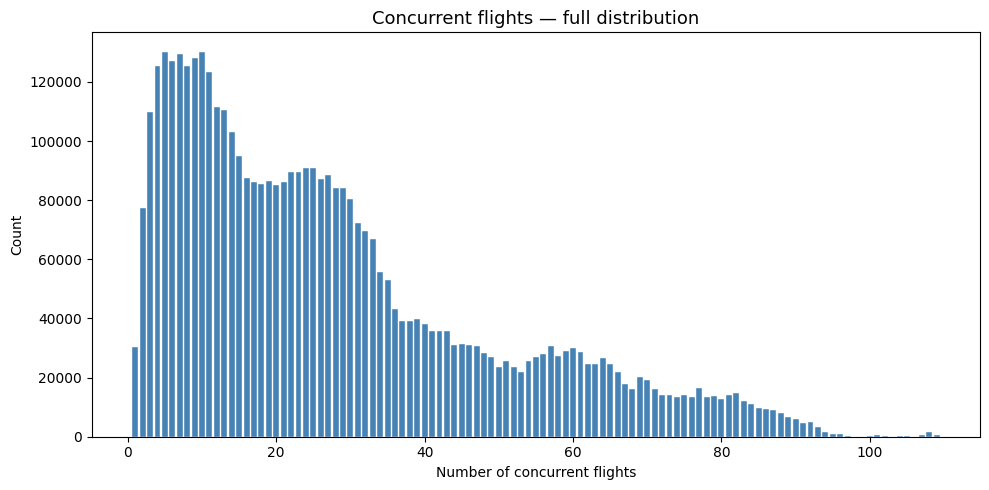

In [184]:
cflights = df_train["CONCURRENT_FLIGHTS"].values

print(f"Maximum value: {df_train['CONCURRENT_FLIGHTS'].max()}")
print(f"Minimum value: {df_train['CONCURRENT_FLIGHTS'].min()}")
print(f"Mean: {df_train['CONCURRENT_FLIGHTS'].mean()}")

values, counts = np.unique(cflights, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(values, counts, color='steelblue', edgecolor='white', linewidth=0.3)
plt.title('Concurrent flights — full distribution', fontsize=13)
plt.xlabel('Number of concurrent flights')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

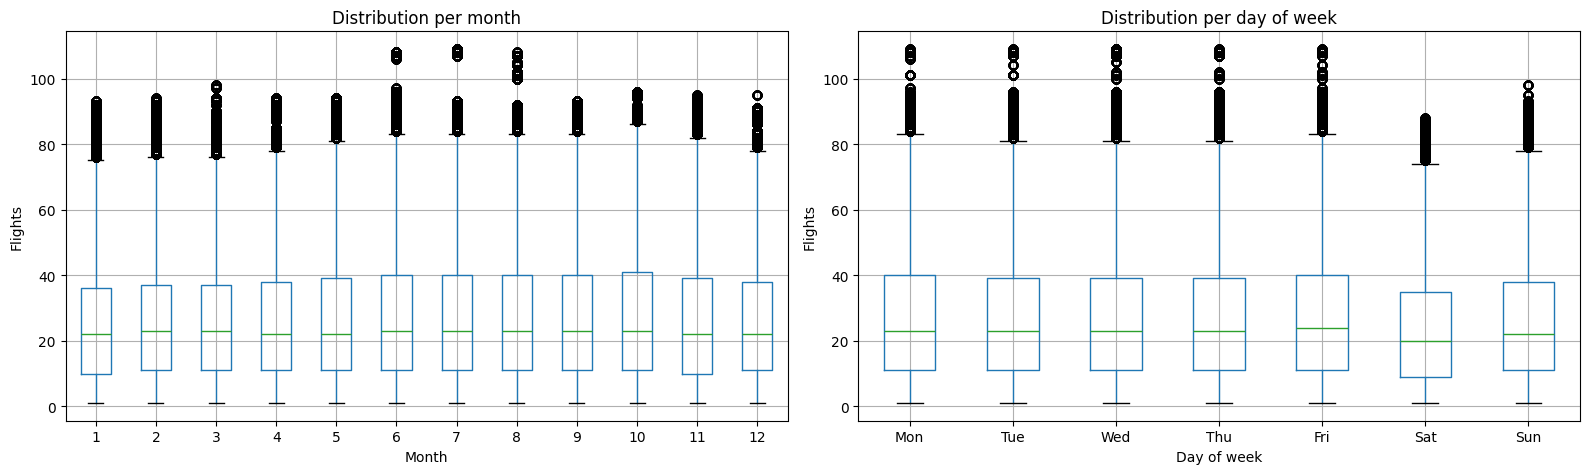

In [172]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_train.boxplot(column="CONCURRENT_FLIGHTS", by="MONTH", ax=axes[0])
axes[0].set_title("Distribution per month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Flights")

df_train.boxplot(column="CONCURRENT_FLIGHTS", by="DAY_OF_WEEK", ax=axes[1])
axes[1].set_title("Distribution per day of week")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Flights")
axes[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], rotation=0)

plt.suptitle("")
plt.tight_layout()
plt.show()

Does not vary much per month nor per day of week

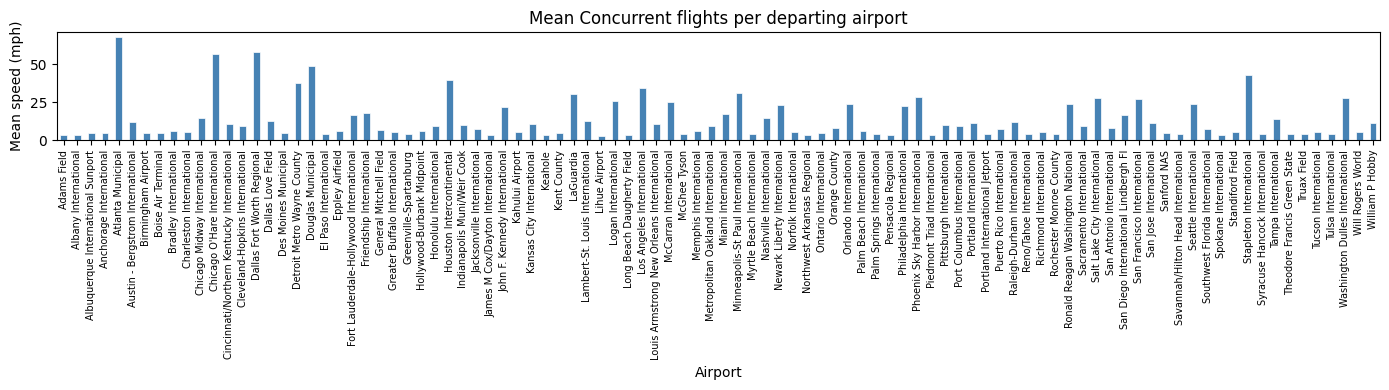

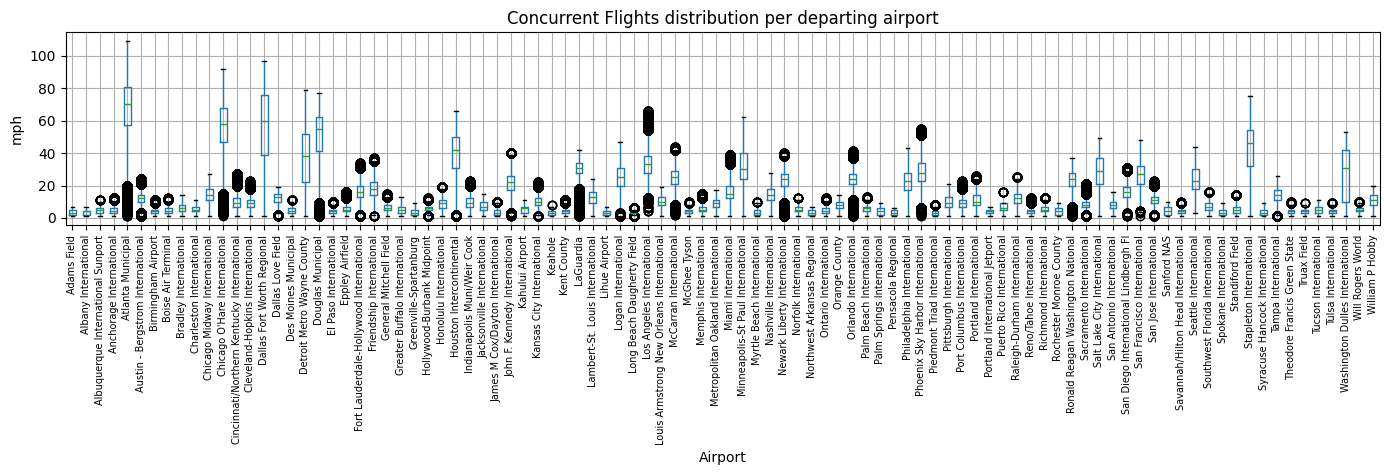

In [ ]:
cf_per_airport = df_train.groupby("DEPARTING_AIRPORT")["CONCURRENT_FLIGHTS"].mean()

fig, ax = plt.subplots(figsize=(14, 4))
cf_per_airport.plot(kind="bar", ax=ax, color="steelblue",edgecolor="white", linewidth=0.5)
ax.set_title("Mean Concurrent flights per departing airport")
ax.set_xlabel("Airport")
ax.set_ylabel("Mean speed (mph)")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

df_train.boxplot(column="CONCURRENT_FLIGHTS", by="DEPARTING_AIRPORT", figsize=(14, 5))
plt.title("Concurrent Flights distribution per departing airport")
plt.suptitle("")
plt.xlabel("Airport")
plt.ylabel("mph")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

Kinda varies but too many

In [ ]:
airport_mean = df_train.groupby("DEPARTING_AIRPORT")["CONCURRENT_FLIGHTS"].mean()
small  = airport_mean.quantile(0.33)
large  = airport_mean.quantile(0.67)

def assign_size(airport):
    mean = airport_mean[airport]
    if mean <= small:
        return "small"
    elif mean <= large:
        return "medium"
    else:
        return "large"

df_train["AIRPORT_SIZE"] = df_train["DEPARTING_AIRPORT"].map(lambda a: assign_size(a))
print(df_train["AIRPORT_SIZE"].value_counts())

AIRPORT_SIZE
large     3375038
medium     864626
small      302679
Name: count, dtype: int64


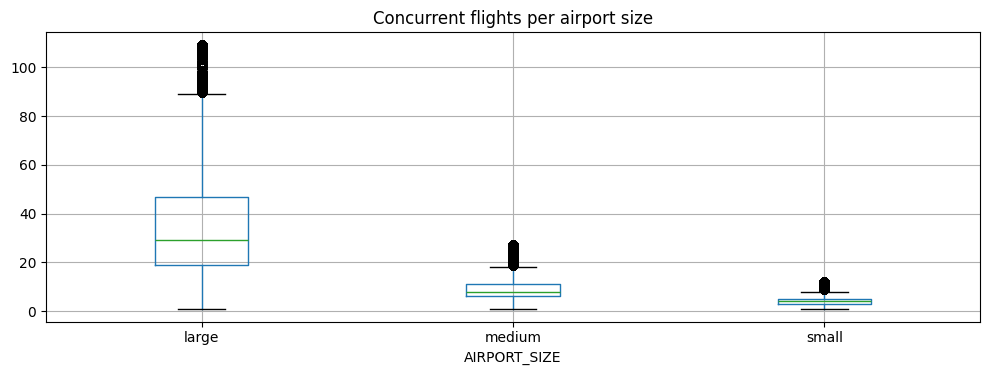

In [ ]:
df_train.boxplot(column="CONCURRENT_FLIGHTS", by="AIRPORT_SIZE", figsize=(10, 4))
plt.suptitle("")
plt.title("Concurrent flights per airport size")
plt.tight_layout()
plt.show()

Good

### Rain

Maximum value of precipitation: 11.63
Minimum value of precipitation: 0.0
Proportion of zero rain days: 0.7020665326242426
Mean (all days): 0.10368144809848133
Mean (rainy days only): 0.34800201874506764


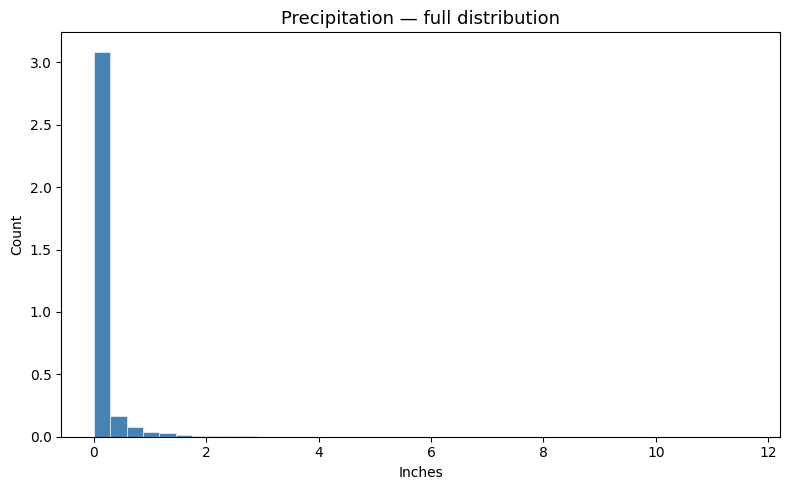

In [ ]:
prcp = df_train["PRCP"].values

print(f"Maximum value of precipitation: {df_train["PRCP"].max()}")
print(f"Minimum value of precipitation: {df_train["PRCP"].min()}")
print(f"Proportion of zero rain days: {(df_train["PRCP"] == 0).mean()}")
print(f"Mean (all days): {df_train["PRCP"].mean()}")
print(f"Mean (rainy days only): {df_train[df_train["PRCP"] > 0]["PRCP"].mean()}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(prcp, bins=40, color="steelblue", edgecolor="white", linewidth=0.4)
ax.set_title("Precipitation — full distribution", fontsize=13)
ax.set_xlabel("Inches")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

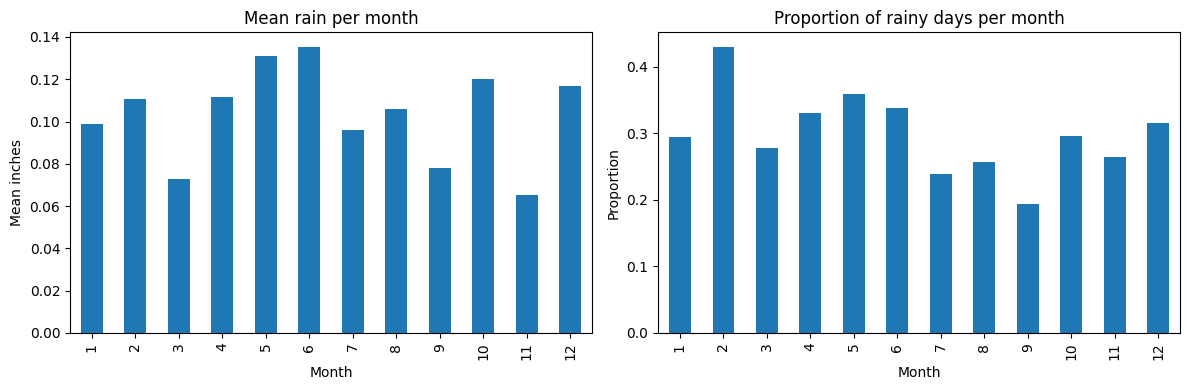

In [ ]:
# mean rain per month
rain_per_month = df_train.groupby("MONTH")["PRCP"].mean()

# number of non-zero rain observations per month
nonzero_per_month = df_train[df_train["PRCP"] > 0].groupby("MONTH")["PRCP"].count()

# total observations per month
total_per_month = df_train.groupby("MONTH")["PRCP"].count()

# proportion of rainy days per month
prop_rainy = nonzero_per_month / total_per_month

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rain_per_month.plot(kind="bar", ax=axes[0], title="Mean rain per month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Mean inches")
prop_rainy.plot(kind="bar", ax=axes[1], title="Proportion of rainy days per month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Proportion")
plt.tight_layout()
plt.show()

Clear variation per month, place it inside month plate

### Wind

Maximum value of wind: 33.78
Minimum value of wind: 0.0
Mean (all days): 8.340974151445632


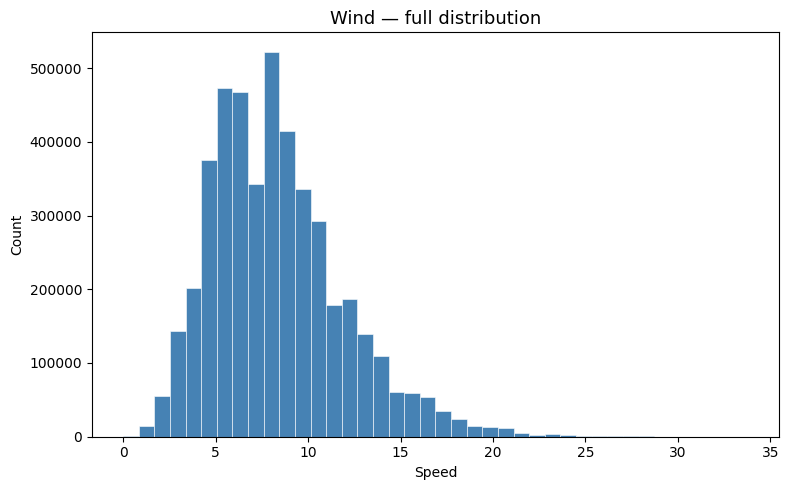

In [ ]:
wind = df_train["WIND"].values

print(f"Maximum value of wind: {df_train["WIND"].max()}")
print(f"Minimum value of wind: {df_train["WIND"].min()}")
print(f"Mean (all days): {df_train["WIND"].mean()}")

plt.figure(figsize=(8, 5))
plt.hist(wind, bins=40, color="steelblue", edgecolor="white", linewidth=0.4)
plt.title("Wind — full distribution", fontsize=13)
plt.xlabel("Speed")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

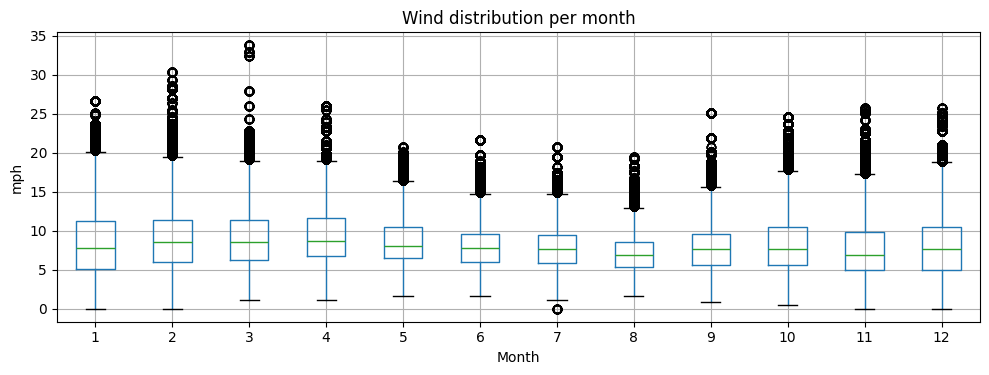

In [ ]:
df_train.boxplot(column="WIND", by="MONTH", figsize=(10, 4))
plt.title("Wind distribution per month")
plt.suptitle("")  # removes the default pandas subtitle
plt.xlabel("Month")
plt.ylabel("mph")
plt.tight_layout()
plt.show()

Should we remove it from month plate?

<Figure size 800x500 with 0 Axes>

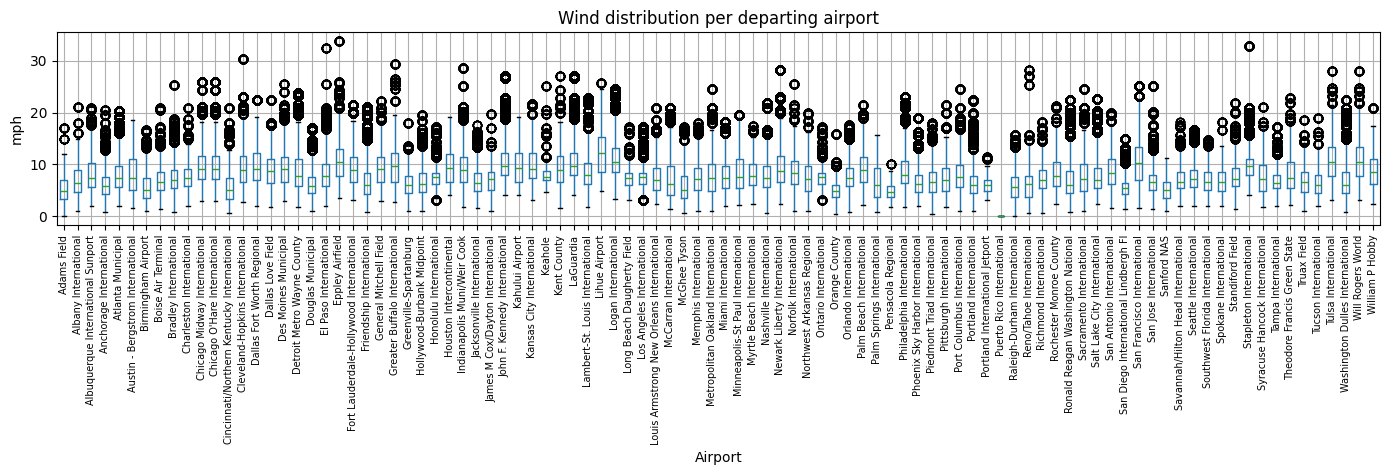

In [ ]:
plt.figure(figsize=(8, 5))
df_train.boxplot(column="WIND", by="DEPARTING_AIRPORT", figsize=(14, 5))
plt.title("Wind distribution per departing airport")
plt.suptitle("")
plt.xlabel("Airport")
plt.ylabel("mph")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

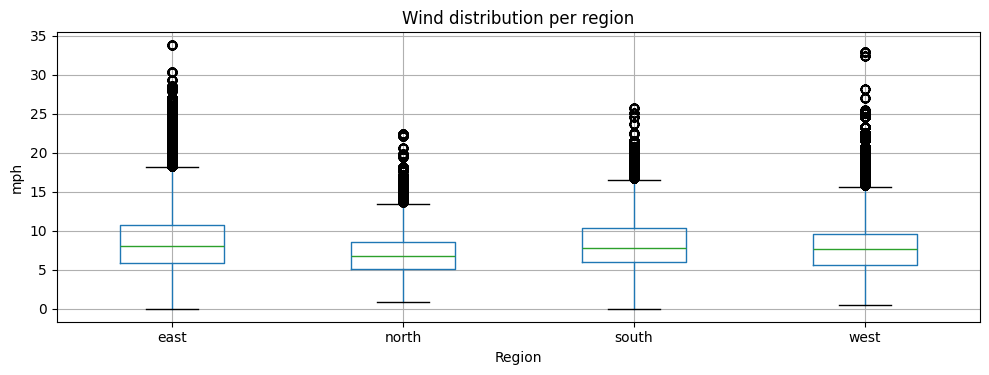

In [173]:
df_train.boxplot(column="WIND", by="REGION", figsize=(10, 4))
plt.suptitle("")
plt.title("Wind distribution per region")
plt.xlabel("Region")
plt.ylabel("mph")
plt.tight_layout()
plt.show()

Not awesome

# 2. Chosen distributions

- DELAY 
- CARRIER_NAME <br>
PLOT DISTRIBUTIONS WITH COMPUTED PARAMETERS TO SEEE


### Rain

- Zero inflated distribution for Gamma distribution
- Fit parameters per month from data

In [ ]:
rain_thresh=0

rain_params = {}
for month in range(1, 13):
    month_data = df_train[df_train["MONTH"] == month]["PRCP"]

    # proportion of no-rain days
    pi_m = (month_data <= rain_thresh).mean()

    # fit gamma on rain days only
    wet_days = month_data[month_data > rain_thresh]
    alpha_m, _, beta_m = gamma.fit(wet_days, floc=0)

    rain_params[month] = {
        "pi": torch.tensor(pi_m,    dtype=torch.float32),
        "alpha": torch.tensor(alpha_m, dtype=torch.float32),
        "beta": torch.tensor(beta_m,  dtype=torch.float32)
    }

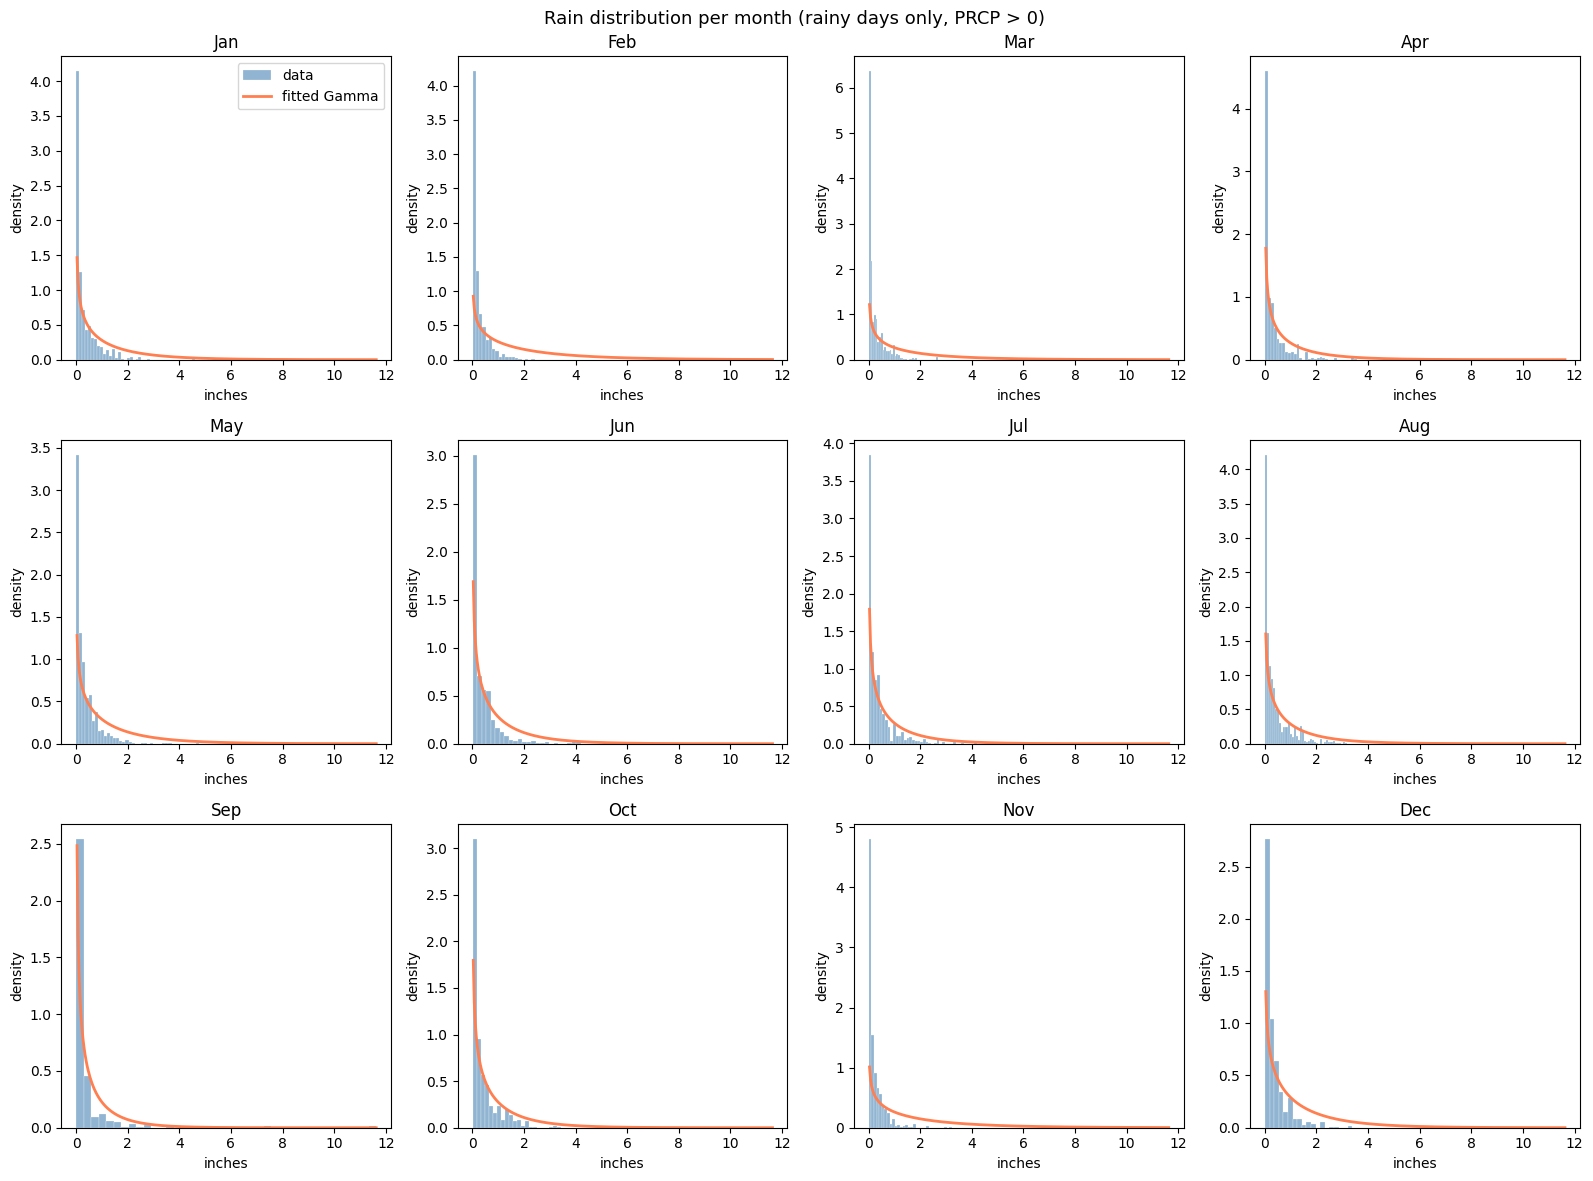

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

x = np.linspace(0, df_train[df_train["PRCP"] > rain_thresh]["PRCP"].max(), 300)
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

for month in range(1, 13):
    ax = axes[month - 1]

    wet_days = df_train[(df_train["MONTH"] == month) & (df_train["PRCP"] > rain_thresh)]["PRCP"].values

    # density true
    ax.hist(wet_days, bins=40, density=True, color="steelblue", edgecolor="white", linewidth=0.3, alpha=0.6, label="data")

    alpha = rain_params[month]["alpha"].item()
    beta  = rain_params[month]["beta"].item()
    pdf   = gamma.pdf(x, a=alpha, scale=1/beta)
    ax.plot(x, pdf, color="coral", linewidth=2, label="fitted Gamma")

    ax.set_title(month_names[month - 1])
    ax.set_xlabel("inches")
    ax.set_ylabel("density")

axes[0].legend()
plt.suptitle(f"Rain distribution per month (rainy days only, PRCP > {rain_thresh})", fontsize=13)
plt.tight_layout()
plt.show()

Good distribution: fix parameter or strong prior?

### Wind

- Weibull distribution, used a lot to model wind speed
- Use global, doesnt vary with other variable 
- maybe set a prior so it can be learned? the problem is then should we also set the others? we can do it if we set strong prior

**Global (per nothing, only inside observation plate)**

In [ ]:
wind_global = df_train["WIND"].values

shape, _, scale = weibull_min.fit(wind_global, floc=0)

wind_params_global = {
    "shape": torch.tensor(shape, dtype=torch.float32),
    "scale": torch.tensor(scale, dtype=torch.float32)
}

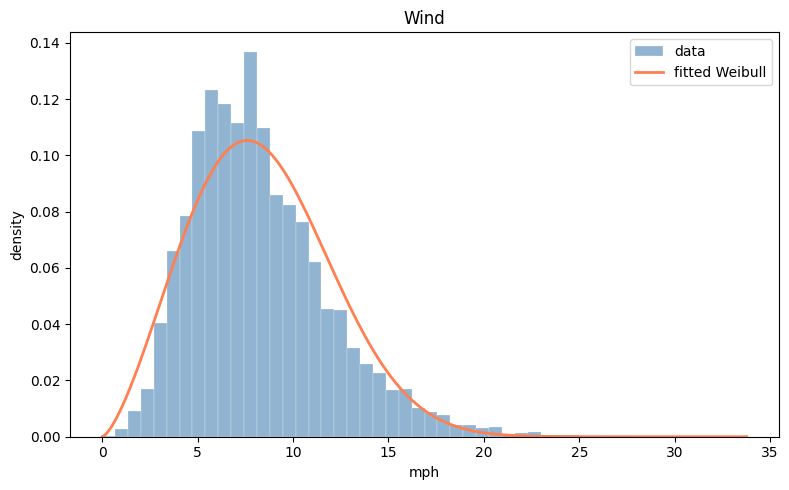

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(wind_global, bins=50, density=True, color="steelblue", edgecolor="white", linewidth=0.3, alpha=0.6, label="data")

x = np.linspace(0, wind_global.max(), 300)
shape = wind_params_global["shape"].item()
scale = wind_params_global["scale"].item()
pdf = weibull_min.pdf(x, c=shape, scale=scale, loc=0)
ax.plot(x, pdf, color="coral", linewidth=2, label="fitted Weibull")

ax.set_title("Wind")
ax.set_xlabel("mph")
ax.set_ylabel("density")
ax.legend()
plt.tight_layout()
plt.show()

Not awesome

**Per month**

In [ ]:
wind_params_month = {}
for month in range(1, 13):
    month_data = df_train[df_train["MONTH"] == month]["WIND"].values

    shape, _, scale = weibull_min.fit(month_data, floc=0)

    wind_params_month[month] = {
        "shape": torch.tensor(shape, dtype=torch.float32),
        "scale": torch.tensor(scale, dtype=torch.float32)
    }

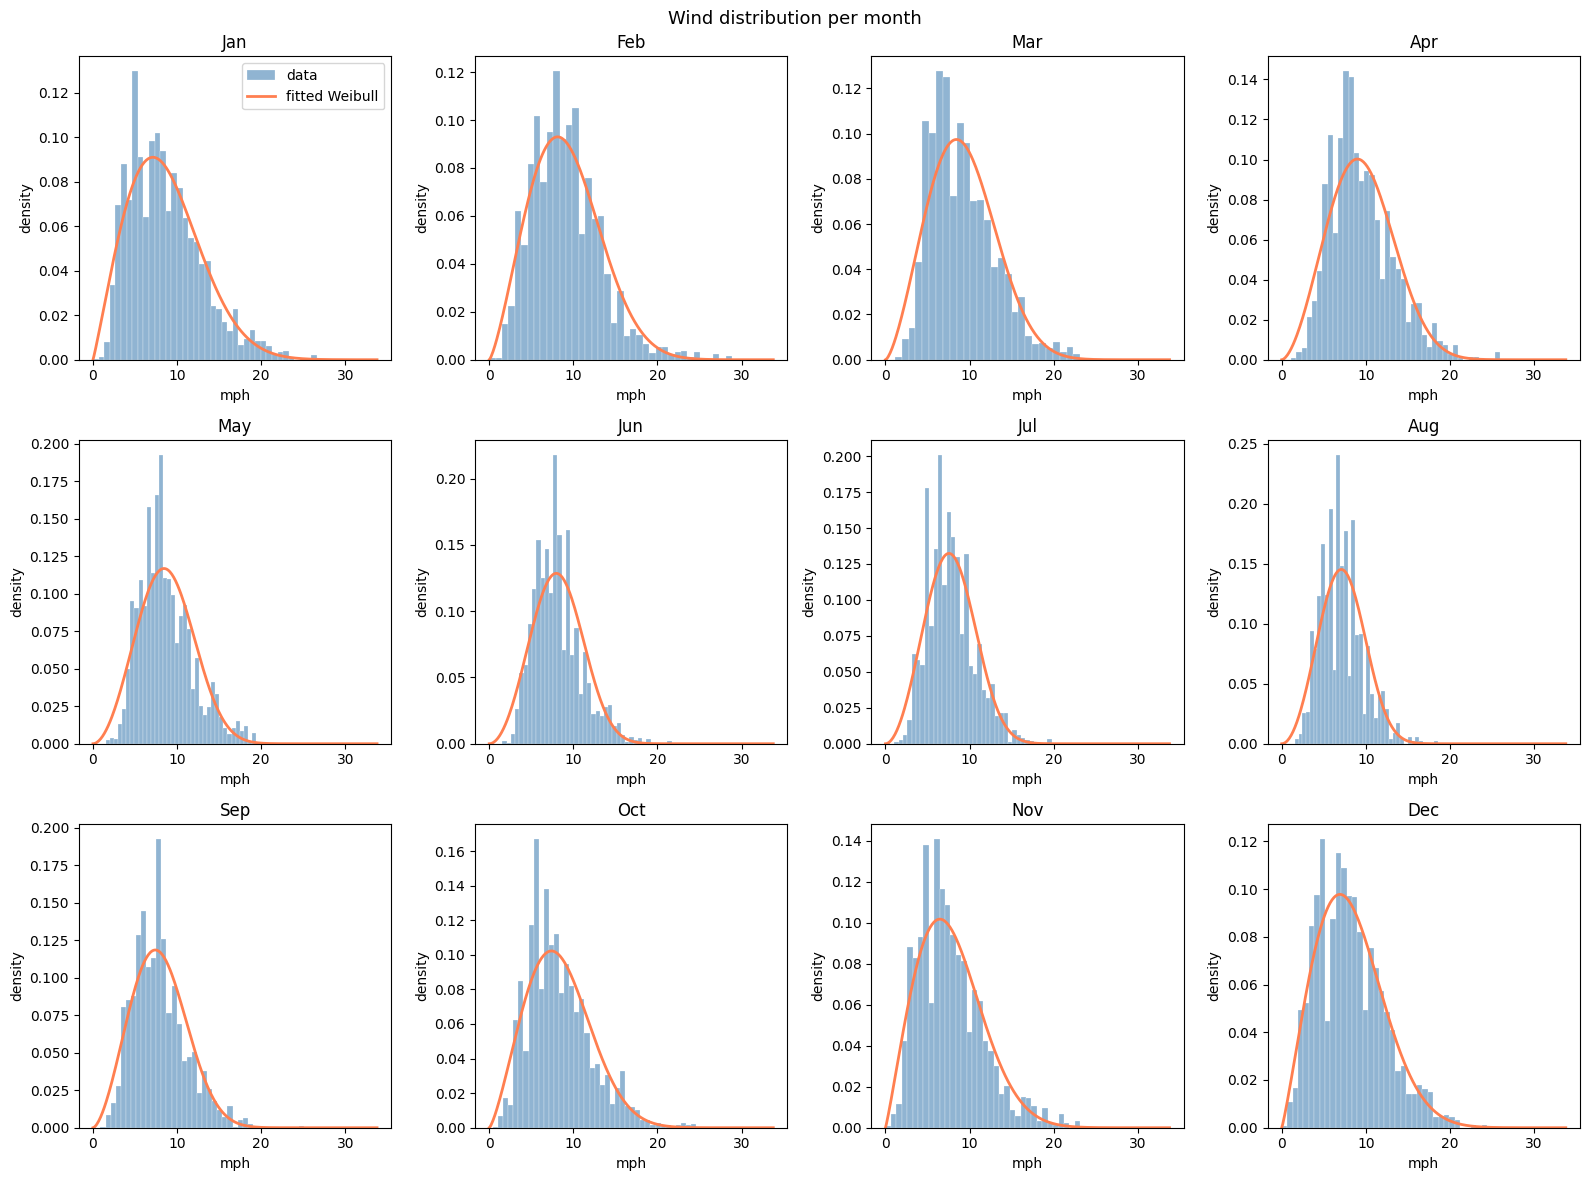

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

x = np.linspace(0, df_train["WIND"].max(), 300)

for month in range(1, 13):
    ax = axes[month - 1]

    month_data = df_train[df_train["MONTH"] == month]["WIND"].values

    ax.hist(month_data, bins=40, density=True, color="steelblue", edgecolor="white", linewidth=0.3, alpha=0.6, label="data")

    shape = wind_params_month[month]["shape"].item()
    scale = wind_params_month[month]["scale"].item()
    pdf   = weibull_min.pdf(x, c=shape, scale=scale, loc=0)
    ax.plot(x, pdf, color="coral", linewidth=2, label="fitted Weibull")

    ax.set_title(month_names[month - 1])
    ax.set_xlabel("mph")
    ax.set_ylabel("density")

axes[0].legend()
plt.suptitle("Wind distribution per month", fontsize=13)
plt.tight_layout()
plt.show()

- curve peaks too late and too smoothly in every month
- left side (1-5) is always lower than it should
- multi peak around 5 9 in every single month

**Per region**

In [176]:
wind_params_region = {}
for region in sorted(df_train['REGION'].unique()):
    region_data = df_train[df_train['REGION'] == region]['WIND'].values
    shape, _, scale = weibull_min.fit(region_data, floc=0)
    wind_params_region[region] = {
        'shape': torch.tensor(shape, dtype=torch.float32),
        'scale': torch.tensor(scale, dtype=torch.float32)
    }

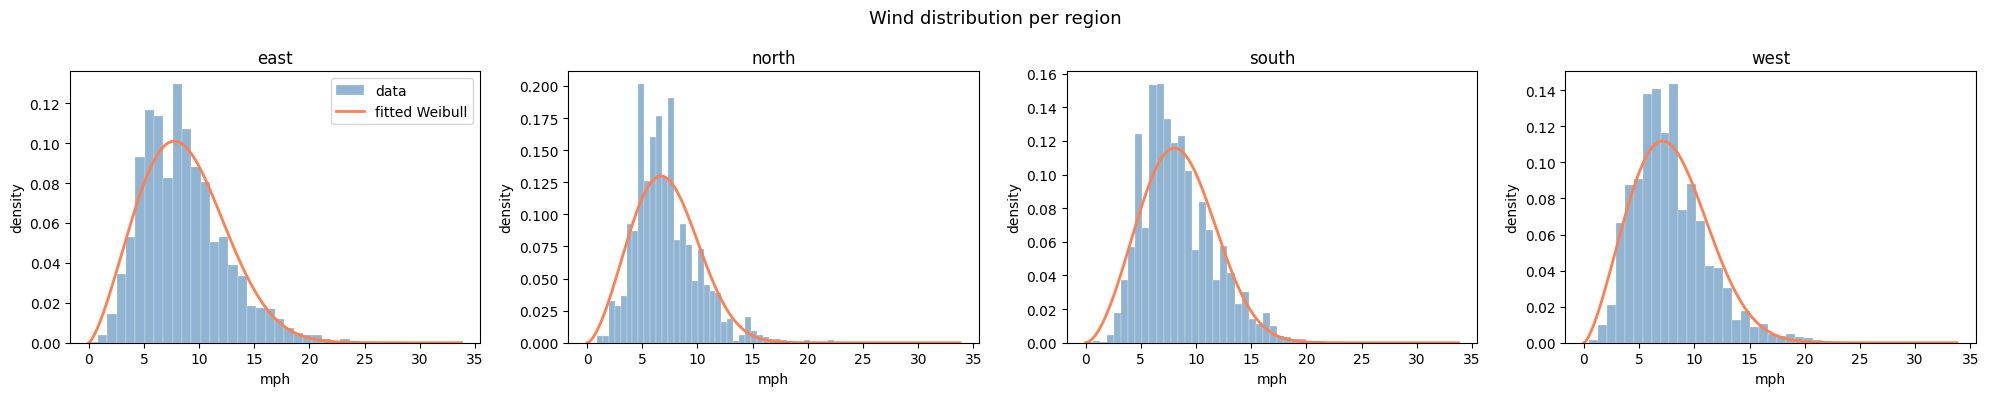

In [177]:
regions = sorted(df_train['REGION'].unique())
n = len(regions)

fig, axes = plt.subplots(1, n, figsize=(5*n, 4))

x = np.linspace(0, df_train['WIND'].max(), 300)

for i, region in enumerate(regions):
    ax = axes[i]

    region_data = df_train[df_train['REGION'] == region]['WIND'].values

    ax.hist(region_data, bins=40, density=True, color='steelblue',
            edgecolor='white', linewidth=0.3, alpha=0.6, label='data')

    shape = wind_params_region[region]['shape'].item()
    scale = wind_params_region[region]['scale'].item()
    pdf   = weibull_min.pdf(x, c=shape, scale=scale, loc=0)
    ax.plot(x, pdf, color='coral', linewidth=2, label='fitted Weibull')

    ax.set_title(region)
    ax.set_xlabel('mph')
    ax.set_ylabel('density')

axes[0].legend()
plt.suptitle('Wind distribution per region', fontsize=13)
plt.tight_layout()
plt.show()

No good stratification, just use global?

### Concurrent flights

- Negative Binomial

In [180]:
flights_global = df_train["CONCURRENT_FLIGHTS"].values

mean = flights_global.mean()
var  = flights_global.var()

p_mom = mean / var
r_mom = mean * p_mom / (1 - p_mom)

concurrent_params = {
    "r": torch.tensor(r_mom, dtype=torch.float32),
    "p": torch.tensor(p_mom, dtype=torch.float32)
}

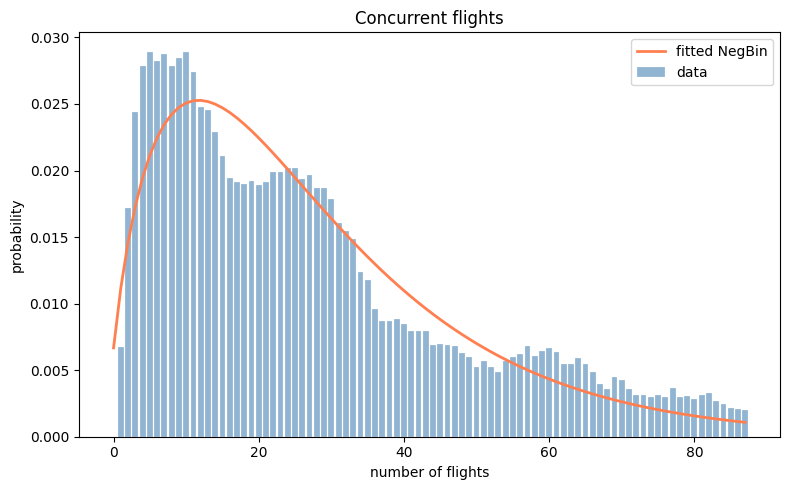

In [181]:
fig, ax = plt.subplots(figsize=(8, 5))

max_flights = int(np.percentile(flights_global, 99))
counts = np.bincount(flights_global[flights_global <= max_flights])
probs  = counts / counts.sum()
ax.bar(range(len(probs)), probs, color="steelblue", edgecolor="white", linewidth=0.3, alpha=0.6, label="data")

r = concurrent_params["r"].item()
p = concurrent_params["p"].item()
k = np.arange(0, max_flights + 1)
pmf = nbinom.pmf(k, n=r, p=p)
ax.plot(k, pmf, color="coral", linewidth=2, label="fitted NegBin")

ax.set_title("Concurrent flights")
ax.set_xlabel("number of flights")
ax.set_ylabel("probability")
ax.legend()
plt.tight_layout()
plt.show()

In [182]:
concurrent_params_size = {}
for size in ['small', 'medium', 'large']:
    size_data = df_train[df_train['AIRPORT_SIZE'] == size]['CONCURRENT_FLIGHTS'].values

    mean = size_data.mean()
    var  = size_data.var()

    p_mom = mean / var
    r_mom = mean * p_mom / (1 - p_mom)

    concurrent_params_size[size] = {
        'r': torch.tensor(r_mom, dtype=torch.float32),
        'p': torch.tensor(p_mom, dtype=torch.float32)
    }

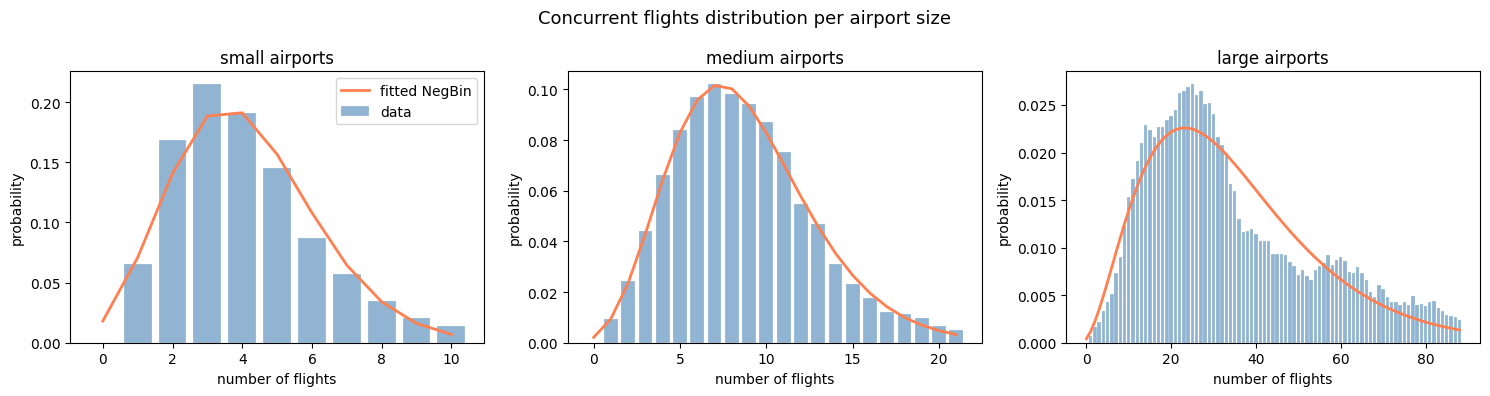

In [183]:
sizes = ['small', 'medium', 'large']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, size in enumerate(sizes):
    ax = axes[i]

    size_data = df_train[df_train['AIRPORT_SIZE'] == size]['CONCURRENT_FLIGHTS'].values

    max_flights = int(np.percentile(size_data, 99))
    counts = np.bincount(size_data[size_data <= max_flights])
    probs  = counts / counts.sum()
    ax.bar(range(len(probs)), probs, color='steelblue',edgecolor='white', linewidth=0.3, alpha=0.6, label='data')

    r = concurrent_params_size[size]['r'].item()
    p = concurrent_params_size[size]['p'].item()
    k = np.arange(0, max_flights + 1)
    pmf = nbinom.pmf(k, n=r, p=p)
    ax.plot(k, pmf, color='coral', linewidth=2, label='fitted NegBin')

    ax.set_title(f'{size} airports')
    ax.set_xlabel('number of flights')
    ax.set_ylabel('probability')

axes[0].legend()
plt.suptitle('Concurrent flights distribution per airport size', fontsize=13)
plt.tight_layout()
plt.show()